# Testing `dataset_cache_794495.md` — can the instructions alone identify errors?

This notebook is a **literal execution of the markdown's instructions**, nothing more.
It loads only `dataset_cache_794495.pkl` (no image, no segmentation mask, no cloud
credentials — exactly the constraint the markdown promises) and tries to reproduce the
split / merge / omit identification using only what the markdown describes.

Each section corresponds to a section of the markdown. Cells `assert` the markdown's
explicit claims, so when you run top-to-bottom the output tells you, per claim, whether
the instruction was **sufficient and correct** or **misleading / incomplete**.

Kernel: **panda**.

## 0. Setup

The markdown says loading "requires the `agentic_neuron_proofreader` package on the path"
and can be done with a plain `pickle.load`. We add the package source to `sys.path` and
do exactly that.

In [1]:
import sys, os, pickle
from collections import defaultdict

import numpy as np
import networkx as nx

# The pickle stores `SkeletonGraph` instances, so the package must be importable.
REPO = "/allen/programs/mindscope/workgroups/auto-model/zihan.zhang/exaspim-agent"
sys.path.insert(0, os.path.join(REPO, "agentic-neuron-proofreader/src"))

minlen = 100
CACHE_PATH = os.path.join(REPO, f"exa-spim-agent/cache/dataset_cache_794495_mcl{minlen}.pkl")

# Track which markdown claims pass / fail so we can summarize at the end.
REPORT = []
def check(claim, ok, detail=""):
    REPORT.append((claim, bool(ok), detail))
    flag = "PASS" if ok else "FAIL"
    print(f"[{flag}] {claim}" + (f"  ->  {detail}" if detail else ""))
    return ok

## 1. Load the cache (markdown § "Loading the cache")

Markdown claims:
- the pickle is a single dict;
- the relevant keys are `anisotropy`, `min_cable_length`, `node_spacing`,
  `fragments_graph`, `gt_graph`;
- `anisotropy == (0.748, 0.748, 1.0)`, `node_spacing == 5`, and `min_cable_length`
  matches the value the cache was built with;
- a plain `pickle.load` works **without** touching the image / credentials.

In [2]:
with open(CACHE_PATH, "rb") as f:
    payload = pickle.load(f)   # markdown: requires agentic_neuron_proofreader importable

check("pickle is a single dict", isinstance(payload, dict), f"type={type(payload).__name__}")
print("keys:", list(payload.keys()))

gt_graph        = payload["gt_graph"]
fragments_graph = payload["fragments_graph"]
anisotropy      = payload["anisotropy"]

for k in ["anisotropy", "min_cable_length", "node_spacing", "fragments_graph", "gt_graph"]:
    check(f"key '{k}' present", k in payload)

check("anisotropy == (0.748, 0.748, 1.0)", tuple(np.round(anisotropy, 3)) == (0.748, 0.748, 1.0),
      str(tuple(anisotropy)))
check(f"min_cable_length == {minlen}", payload.get("min_cable_length") == minlen, str(payload.get("min_cable_length")))
check("node_spacing == 5", payload.get("node_spacing") == 5, str(payload.get("node_spacing")))

[PASS] pickle is a single dict  ->  type=dict
keys: ['fragments_path', 'gt_path', 'img_path', 'anisotropy', 'min_cable_length', 'node_spacing', 'fragments_graph', 'gt_graph']
[PASS] key 'anisotropy' present
[PASS] key 'min_cable_length' present
[PASS] key 'node_spacing' present
[PASS] key 'fragments_graph' present
[PASS] key 'gt_graph' present
[PASS] anisotropy == (0.748, 0.748, 1.0)  ->  (0.748, 0.748, 1.0)
[PASS] min_cable_length == 100  ->  100
[PASS] node_spacing == 5  ->  5


True

In [3]:
# Markdown sample code: graph summaries.
print(gt_graph.summary(prefix="GroundTruth"))
print(fragments_graph.summary(prefix="Fragments"))

GroundTruth Graph
# Connected Components: 19
# Nodes: 1,363,808
# Edges: 1,363,789
Memory Consumption: 18.66 GBs
Fragments Graph
# Connected Components: 366,915
# Nodes: 20,876,161
# Edges: 20,509,246
Memory Consumption: 18.67 GBs


## 2. Component counts (markdown § "Working with the graph")

A connected component in `gt_graph` is one traced neuron; in `fragments_graph`
it is one UNet fragment. The fragment count depends on the `min_cable_length`
used to build the cache, so we just report both counts.

In [4]:
n_gt   = nx.number_connected_components(gt_graph)
n_frag = nx.number_connected_components(fragments_graph)
print("GT components:  ", n_gt)
print("Frag components:", n_frag)

# A GT component is one traced neuron; a fragment component is one UNet fragment.
# (Fragment count depends on min_cable_length, so we report it rather than assert a range.)
check("both graphs have components to compare", n_gt > 0 and n_frag > 0,
      f"GT={n_gt}, frags={n_frag}")

GT components:   19
Frag components: 366915
[PASS] both graphs have components to compare  ->  GT=19, frags=366915


True

## 3. The GT / predicted namespace split (markdown § "SWC ID vs segment ID")

This is the subtle claim the markdown was corrected to make explicit:
- `node_segment_id` exists on **both** graphs (same class);
- on `gt_graph` it returns the **GT neuron's own name** `N0XX-794495-<initials>` — *not* a prediction;
- on `fragments_graph` it returns the **raw U-Net segment label** — the predicted identity;
- a GT node carries **no predicted label** until matched against `fragments_graph`.

If the markdown is right, the two graphs' segment-id namespaces should be disjoint in style.

In [5]:
gt_node = next(iter(gt_graph.nodes))
print("gt_graph.node_swc_id     :", gt_graph.node_swc_id(gt_node))
print("gt_graph.node_segment_id :", gt_graph.node_segment_id(gt_node))

frag_node = next(iter(fragments_graph.nodes))
print("fragments_graph.node_swc_id     :", fragments_graph.node_swc_id(frag_node))
print("fragments_graph.node_segment_id :", fragments_graph.node_segment_id(frag_node))

# Collect the distinct segment-id namespaces of each graph.
gt_segids   = {gt_graph.node_segment_id(n)   for n in gt_graph.nodes}
frag_segids = {fragments_graph.node_segment_id(n) for n in fragments_graph.nodes}

gt_named_like_neuron = all("794495" in s for s in gt_segids)
check("gt_graph segment ids look like GT neuron names (contain '794495')",
      gt_named_like_neuron, f"examples: {sorted(gt_segids)[:3]}")
check("GT and fragment segment-id namespaces are disjoint",
      gt_segids.isdisjoint(frag_segids),
      f"#gt_ids={len(gt_segids)}, #frag_ids={len(frag_segids)}, overlap={len(gt_segids & frag_segids)}")

gt_graph.node_swc_id     : N007-794495-JG.0
gt_graph.node_segment_id : N007-794495-JG
fragments_graph.node_swc_id     : 32323215387.0
fragments_graph.node_segment_id : 32323215387
[PASS] gt_graph segment ids look like GT neuron names (contain '794495')  ->  examples: ['N001-794495-JT', 'N002-794495-PP', 'N003-794495-SP']
[PASS] GT and fragment segment-id namespaces are disjoint  ->  #gt_ids=19, #frag_ids=366904, overlap=0


True

## 4. Label each GT node by nearest fragment segment (markdown § "Identifying errors", step 1)

Markdown step 1: for every GT node, query `fragments_graph.kdtree` for the nearest fragment
node; if within a tolerance ("~a few µm"), assign that fragment's **segment id** as the GT
node's predicted label; otherwise the node is unlabeled (`"0"`).

The tolerance is *not* a stored constant — the markdown only says "~a few µm". We make that
explicit here and treat it as the one free parameter the markdown leaves to the reader. This
is itself a test of whether the markdown is self-contained enough to act on.

In [6]:
MATCH_TOL_UM = 5.0   # markdown only says "~a few µm"; reader's choice. Flagged as a gap below.

# Vectorized nearest-fragment query over all GT nodes at once.
# node_xyz is (N,3) in (x,y,z) microns; kdtree is built over fragment node_xyz (same space).
gt_xyz = gt_graph.node_xyz                       # (N_gt, 3) microns
dists, nn_frag_nodes = fragments_graph.kdtree.query(gt_xyz)

# Map each nearest fragment node -> its U-Net segment id; threshold by tolerance.
gt_pred_label = {}
for gt_n in gt_graph.nodes:
    d = float(dists[gt_n])
    if d <= MATCH_TOL_UM:
        gt_pred_label[gt_n] = fragments_graph.node_segment_id(int(nn_frag_nodes[gt_n]))
    else:
        gt_pred_label[gt_n] = "0"   # unlabeled

n_labeled   = sum(1 for v in gt_pred_label.values() if v != "0")
n_unlabeled = sum(1 for v in gt_pred_label.values() if v == "0")
print(f"GT nodes total: {gt_graph.number_of_nodes()}")
print(f"  labeled (within {MATCH_TOL_UM} µm of a fragment): {n_labeled}")
print(f"  unlabeled (-> omit):                              {n_unlabeled}")
print(f"  median GT->fragment distance: {np.median(dists):.2f} µm")

check("step 1 runs: every GT node received a predicted label or '0'",
      len(gt_pred_label) == gt_graph.number_of_nodes(),
      f"{len(gt_pred_label)} labels for {gt_graph.number_of_nodes()} nodes")

GT nodes total: 1363808
  labeled (within 5.0 µm of a fragment): 1303798
  unlabeled (-> omit):                              60010
  median GT->fragment distance: 1.57 µm
[PASS] step 1 runs: every GT node received a predicted label or '0'  ->  1363808 labels for 1363808 nodes


True

## 5. Classify each GT edge: omit / split / correct (markdown § "Identifying errors", step 2)

Markdown step 2, walking each GT edge `(i, j)`. This mirrors
`OmitEdgePercentMetric.count_omit_edges` in `segmentation_skeleton_metrics`, whose
current criterion is **`node_label[i] == "0" or node_label[j] == "0"`**:
- **omit**  — *either* endpoint unlabeled (`"0"`);
- **split** — both labeled but the segment ids differ;
- **correct** — same nonzero segment id on both ends.

Note the omit rule is an **OR over the two endpoints**, not "both unlabeled": an edge
that touches even one unlabeled node is an omit edge. (There is therefore no separate
"boundary" / one-end-labeled category — those edges are omits.)

We report the % split / omit / correct edges.

In [ ]:
n_omit = n_split = n_correct = 0
for i, j in gt_graph.edges:
    li, lj = gt_pred_label[i], gt_pred_label[j]
    if li == "0" or lj == "0":
        # omit: EITHER endpoint unlabeled (matches count_omit_edges' OR rule)
        n_omit += 1
    elif li != lj:
        n_split += 1
    else:
        n_correct += 1

E = gt_graph.number_of_edges()
print(f"GT edges: {E}")
print(f"  split edges:   {n_split:6d}  ({100*n_split/E:.2f} %)")
print(f"  omit edges:    {n_omit:6d}  ({100*n_omit/E:.2f} %)")
print(f"  correct edges: {n_correct:6d}  ({100*n_correct/E:.2f} %)")

check("step 2 runs: edges classified into omit/split/correct", E > 0,
      f"split={n_split}, omit={n_omit}, correct={n_correct}")

## 6. Count splits per neuron (markdown § "Identifying errors", step 3)

Markdown step 3: splits for a GT neuron = `(# distinct predicted segment ids touching it) − 1`.

In [8]:
# Group GT nodes by their GT neuron (its own segment id), collect predicted labels touching it.
neuron_to_pred_labels = defaultdict(set)
for gt_n in gt_graph.nodes:
    neuron = gt_graph.node_segment_id(gt_n)          # GT neuron name
    lab = gt_pred_label[gt_n]
    if lab != "0":
        neuron_to_pred_labels[neuron].add(lab)

splits_per_neuron = {n: max(len(labs) - 1, 0) for n, labs in neuron_to_pred_labels.items()}
total_splits = sum(splits_per_neuron.values())
avg_splits   = total_splits / max(len(splits_per_neuron), 1)

print(f"neurons with >=1 predicted label: {len(splits_per_neuron)}")
print(f"Total Splits: {total_splits}")
print(f"Avg. Splits per Neuron: {avg_splits:.1f}")
for n in sorted(splits_per_neuron)[:5]:
    print(f"   {n}: {splits_per_neuron[n]} splits")

check("step 3 runs: split counts produced per neuron", len(splits_per_neuron) > 0,
      f"total={total_splits}")

neurons with >=1 predicted label: 19
Total Splits: 3278
Avg. Splits per Neuron: 172.5
   N001-794495-JT: 59 splits
   N002-794495-PP: 141 splits
   N003-794495-SP: 240 splits
   N004-794495-JG: 302 splits
   N005-794495-HP: 223 splits
[PASS] step 3 runs: split counts produced per neuron  ->  total=3278


True

## 7. Detect merges (markdown § "Identifying errors", step 4)

Markdown step 4: a merge is a **single predicted segment id that maps onto two or more
distinct GT neurons**. The markdown's geometric description (walk a fragment, >~50 µm away,
re-approaches a different GT neuron) needs the mask to do exactly; with cache-only data we
test the *core* definition: one segment touching multiple GT neurons.

In [9]:
MERGE_DIST_UM = 50.0   # markdown's '> ~50 µm' threshold for merge reasoning

# For each predicted segment, which GT neurons does it land near (within MATCH_TOL_UM)?
pred_label_to_neurons = defaultdict(set)
for gt_n in gt_graph.nodes:
    lab = gt_pred_label[gt_n]
    if lab != "0":
        pred_label_to_neurons[lab].add(gt_graph.node_segment_id(gt_n))

merged_segments = {lab: neurons for lab, neurons in pred_label_to_neurons.items() if len(neurons) >= 2}
# A segment touching k GT neurons contributes (k-1) merge events (markdown step-3-style counting).
total_merges = sum(len(neurons) - 1 for neurons in merged_segments.values())

print(f"predicted segments touching >=2 GT neurons: {len(merged_segments)}")
print(f"Total Merges: {total_merges}")
for lab, neurons in list(merged_segments.items())[:5]:
    print(f"   segment {lab} merges: {sorted(neurons)}")

check("step 4 runs: merge candidates identified", isinstance(total_merges, int),
      f"segments={len(merged_segments)}, merges={total_merges}")

predicted segments touching >=2 GT neurons: 44
Total Merges: 46
   segment 23809407743 merges: ['N007-794495-JG', 'N009-794495-MB']
   segment 21732994834 merges: ['N007-794495-JG', 'N009-794495-MB']
   segment 16513939829 merges: ['N007-794495-JG', 'N009-794495-MB']
   segment 27435387575 merges: ['N007-794495-JG', 'N009-794495-MB']
   segment 27404009723 merges: ['N003-794495-SP', 'N007-794495-JG']
[PASS] step 4 runs: merge candidates identified  ->  segments=44, merges=46


True

## 7a. Approximate the segmentation mask from skeletons (no cloud read)

Sections 4–7 stand in for the missing segmentation mask with a **nearest-fragment
KDTree** proxy: a GT node gets the segment id of its closest fragment *node*. The
canonical pipeline instead reads the predicted label from the dense **segmentation
volume** at the GT node's voxel. We can get much closer to that — still **cache-only,
no cloud read** — by *reconstructing an approximate mask from the fragment skeletons*
we already have (the idea from `load_skeletons_from_cache.ipynb`):

1. take the UNet fragment skeleton **edges** inside a patch (`edges_in_patch`),
2. **rasterize** each edge into a zeroed volume with `make_digital_line`, writing
   that fragment's **segment id** into the voxels (a *labeled* mask, not just binary),
3. **dilate** the thin center-lines so each neurite fills a neuron-thick tube.

Reading this approximate volume at each GT voxel then labels GT nodes the same way
the real mask would — and we can run the exact step 2–4 error identification on those
labels. Below we (a) build the labeled mask, (b) classify edges from it, and
(c) cross-check it against the section-4 KDTree proxy on the same nodes. Working on a
patch keeps the dense volume small enough to hold in memory.

> **Why this is a better proxy than nearest-node.** The KDTree proxy only matches a
> GT node if a fragment *node* happens to land within `MATCH_TOL_UM`; nodes between
> fragment samples fall through and become false omits. The dilated mask fills the
> space *between* skeleton nodes, so it recovers those in-between GT nodes — closer to
> what reading the dense mask would do. (It is still imperfect: dilation is a uniform
> tube, not the true per-voxel segmentation.)

In [ ]:
from scipy import ndimage
from agentic_neuron_proofreader.utils import geometry_util

# --- Pick a patch (cache-only: center on a GT node, read its voxel coord) -----
PATCH_SHAPE     = (256, 256, 256)   # (z, y, x) voxels
DILATION_RADIUS = 3                 # voxels; ~ how thick we make each neurite
center_node  = next(iter(gt_graph.nodes))
center_voxel = gt_graph.node_voxel(center_node)                  # (z, y, x)
offset = tuple(int(c - s // 2) for c, s in zip(center_voxel, PATCH_SHAPE))

# --- Fragment skeleton edges inside the patch, WITH their component ids -------
# edges_in_patch returns local (z, y, x) voxel coords; component id -> segment id.
frag_edges, frag_comps = fragments_graph.edges_in_patch(
    offset, PATCH_SHAPE, return_components=True
)
comp_to_seg = {int(c): fragments_graph.component_id_to_swc_id[int(c)].split(".")[0]
               for c in np.unique(frag_comps)}

def labeled_mask_from_edges(edges, comps, patch_shape, dilation_radius=3):
    """Approximate the segmentation mask from skeletons alone (NO cloud read).

    1. rasterize each fragment edge into a thin center-line (make_digital_line),
       writing that fragment's SEGMENT id (not just 1) into the volume;
    2. dilate each labeled voxel out to `dilation_radius`, nearest-label wins,
       so the thin lines grow into neuron-thick segment territories.
    Returns an int32 volume of segment "codes" + a code->segment-id dict.
    """
    seg_ids = sorted({comp_to_seg[int(c)] for c in comps})
    seg_to_code = {s: k + 1 for k, s in enumerate(seg_ids)}      # 0 reserved = background
    code_to_seg = {k + 1: s for k, s in enumerate(seg_ids)}
    vol = np.zeros(patch_shape, dtype=np.int32)
    upper = np.array(patch_shape) - 1
    for (start, end), c in zip(edges, comps):                    # step 1: rasterize
        line = geometry_util.make_digital_line(
            np.round(start).astype(int), np.round(end).astype(int))
        line = np.clip(line, 0, upper)
        vol[line[:, 0], line[:, 1], line[:, 2]] = seg_to_code[comp_to_seg[int(c)]]
    if dilation_radius > 0 and vol.any():                        # step 2: dilate w/ labels
        dist, (iz, iy, ix) = ndimage.distance_transform_edt(vol == 0, return_indices=True)
        grown = vol[iz, iy, ix]
        grown[dist > dilation_radius] = 0
        vol = grown
    return vol, code_to_seg

approx_vol, code_to_seg = labeled_mask_from_edges(
    frag_edges, frag_comps, PATCH_SHAPE, DILATION_RADIUS)
print(f"patch {PATCH_SHAPE} @ offset {offset}: {len(frag_edges)} fragment edges rasterized")
print(f"approx mask: {int((approx_vol > 0).sum()):,} labeled voxels, "
      f"{len(code_to_seg)} distinct segments")
check("7a: approximate mask built from skeletons alone (no cloud read)",
      approx_vol.any(), f"{int((approx_vol > 0).sum())} labeled voxels")

# --- Step 1 (mask version): label each GT node by reading the approx mask -----
# This mirrors the CANONICAL pipeline (read the predicted label at the GT voxel),
# but off our skeleton-approximated mask instead of the cloud segmentation.
gt_local_patch, gt_ids_patch = gt_graph.nodes_in_patch(offset, PATCH_SHAPE, return_ids=True)
gl = np.clip(np.round(gt_local_patch).astype(int), 0, np.array(PATCH_SHAPE) - 1)
codes = approx_vol[gl[:, 0], gl[:, 1], gl[:, 2]]
approx_label = {int(nid): (code_to_seg[c] if c else "0")
                for nid, c in zip(gt_ids_patch, codes)}
idset = set(int(n) for n in gt_ids_patch)

# --- Steps 2-4 on the approx-mask labels (same omit-OR logic as sections 5-7) -
n_omit = n_split = n_correct = 0
for i, j in gt_graph.edges:
    if i in idset and j in idset:
        li, lj = approx_label[i], approx_label[j]
        if li == "0" or lj == "0":          # omit: EITHER endpoint unlabeled
            n_omit += 1
        elif li != lj:
            n_split += 1
        else:
            n_correct += 1
E_patch = n_omit + n_split + n_correct
print(f"\napprox-mask edge classification (in-patch GT edges = {E_patch}):")
print(f"  correct={n_correct}  split={n_split}  omit={n_omit}")
check("7a: error identification (steps 2-4) runs on approx-mask labels", E_patch > 0,
      f"correct={n_correct}, split={n_split}, omit={n_omit}")

# --- Cross-check the approx mask against the KDTree proxy on the SAME nodes ----
# Where both methods assign a (nonzero) label, do they agree on the segment id?
both = match = lab_mask = lab_kd = 0
for nid in gt_ids_patch:
    la, lk = approx_label[int(nid)], gt_pred_label[int(nid)]
    lab_mask += la != "0"
    lab_kd   += lk != "0"
    if la != "0" and lk != "0":
        both += 1
        match += (la == lk)
print(f"\nGT nodes in patch: {len(gt_ids_patch)}  "
      f"| approx-mask labeled {lab_mask}, KDTree proxy labeled {lab_kd}")
print(f"segment-id agreement where BOTH label a node: "
      f"{(100*match/both if both else float('nan')):.1f}%  ({match}/{both})")
check("7a: approx-mask and KDTree proxy assign the SAME segment id where both label",
      both > 0 and match / both > 0.95, f"{match}/{both} agree")

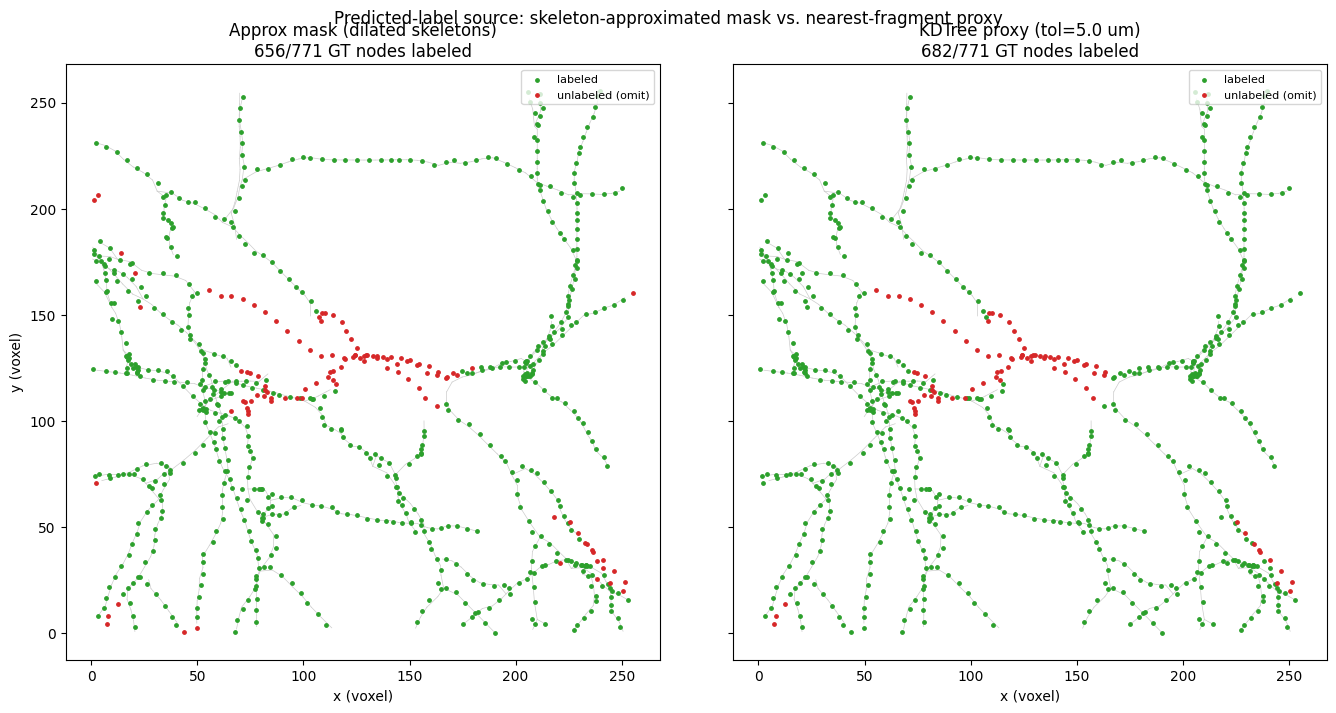

In [11]:
# Side-by-side: GT nodes in the patch labeled by the APPROX MASK (left) vs the
# KDTree nearest-fragment proxy used in sections 4-7 (right). Grey = fragment
# skeleton edges rasterized into the mask; green = labeled GT node; red =
# unlabeled (-> omit). Same data, two ways of reading the predicted label.
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 7), sharex=True, sharey=True)
xs, ys = gt_local_patch[:, 2], gt_local_patch[:, 1]   # plot the (x, y) projection
labelings = [
    ("Approx mask (dilated skeletons)", [approx_label[int(n)] for n in gt_ids_patch]),
    (f"KDTree proxy (tol={MATCH_TOL_UM} um)", [gt_pred_label[int(n)] for n in gt_ids_patch]),
]
for ax, (title, labs) in zip(axes, labelings):
    for (s, e) in frag_edges:                          # rasterized fragment lines
        ax.plot([s[2], e[2]], [s[1], e[1]], color="#cccccc", lw=0.5, zorder=1)
    labeled = np.array([l != "0" for l in labs])
    ax.scatter(xs[labeled],  ys[labeled],  s=6, c="#2ca02c", label="labeled",          zorder=3)
    ax.scatter(xs[~labeled], ys[~labeled], s=6, c="#d62728", label="unlabeled (omit)", zorder=3)
    ax.set_title(f"{title}\n{int(labeled.sum())}/{len(labs)} GT nodes labeled")
    ax.set_aspect("equal"); ax.set_xlabel("x (voxel)")
    ax.legend(loc="upper right", fontsize=8)
axes[0].set_ylabel("y (voxel)")
fig.suptitle("Predicted-label source: skeleton-approximated mask vs. nearest-fragment proxy")
fig.tight_layout()
plt.show()

## 7b. Visualize the errors

These plots render directly from the skeleton coordinates (`node_xyz`) and the
edge classification computed above — **cache-only, no image**. They make the
split / omit / correct labels visible so you can eyeball whether the markdown's
identification procedure is behaving sensibly.

Color convention used throughout (matches the omit-OR rule from section 5):
- **green**  = correctly reconstructed GT edge (both ends share one predicted segment)
- **orange** = split edge (both ends labeled, but with different predicted segments)
- **red**    = omit edge (at least one end unlabeled — the `node_label == "0"` OR rule)

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D
import os

EDGE_COLORS = {"correct": "#2ca02c", "split": "#ff7f0e", "omit": "#d62728"}

def classify_edge(i, j):
    """Same logic as section 5: omit = EITHER endpoint unlabeled ('0')."""
    li, lj = gt_pred_label[i], gt_pred_label[j]
    if li == "0" or lj == "0":
        return "omit"
    return "correct" if li == lj else "split"

# Precompute (edge -> classification) once for all plots below.
edge_class = {(i, j): classify_edge(i, j) for i, j in gt_graph.edges}

def project(xyz):
    """node_xyz is (x, y, z) microns; plot the (x, y) projection."""
    return xyz[0], xyz[1]

legend_handles = [Line2D([0], [0], color=c, lw=2, label=k) for k, c in EDGE_COLORS.items()]

FIGS_DIR = os.path.join(os.path.dirname(CACHE_PATH), "..", "notebooks", "figs_markdown_test")
os.makedirs(FIGS_DIR, exist_ok=True)
print("figures will be saved to:", os.path.abspath(FIGS_DIR))

### Plot 1 — whole-brain GT skeletons colored by error type

Every GT edge drawn in the (x, y) projection, colored by its classification.
Orange clusters = where the automated reconstruction splits a neuron; red = missed
stretches; green = recovered.

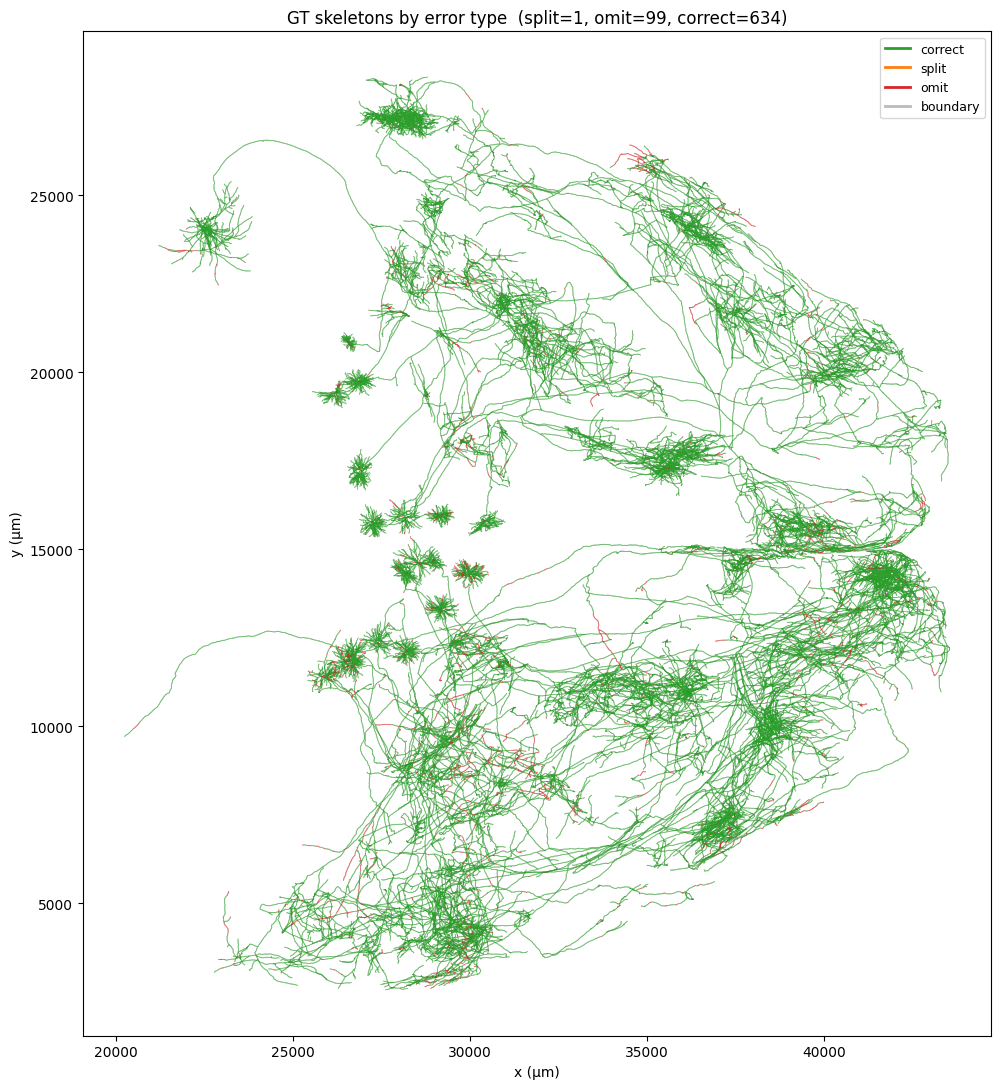

In [13]:
segs, cols = [], []
for (i, j), cls in edge_class.items():
    (xi, yi), (xj, yj) = project(gt_graph.node_xyz[i]), project(gt_graph.node_xyz[j])
    segs.append([(xi, yi), (xj, yj)])
    cols.append(EDGE_COLORS[cls])

fig, ax = plt.subplots(figsize=(11, 11))
ax.add_collection(LineCollection(segs, colors=cols, linewidths=0.6))
ax.autoscale(); ax.set_aspect("equal")
ax.set_xlabel("x (µm)"); ax.set_ylabel("y (µm)")
ax.set_title(f"GT skeletons by error type  (split={n_split}, omit={n_omit}, correct={n_correct})")
ax.legend(handles=legend_handles, loc="upper right", fontsize=9)
fig.tight_layout()
# fig.savefig(os.path.join(FIGS_DIR, "01_wholebrain_error_types.png"), dpi=150)
plt.show()

### Plot 2 — per-neuron error breakdown

Stacked bar of correct / split / omit edge counts for each of the 19
GT neurons. Shows how unevenly errors distribute across neurons (the markdown's
'error rates vary by morphology/annotator' point).

In [ ]:
per_neuron = defaultdict(lambda: defaultdict(int))
for (i, j), cls in edge_class.items():
    neuron = gt_graph.node_segment_id(i)   # both endpoints share a GT neuron (same component)
    per_neuron[neuron][cls] += 1

neurons = sorted(per_neuron)
order = ["correct", "split", "omit"]
counts = {c: [per_neuron[n][c] for n in neurons] for c in order}

fig, ax = plt.subplots(figsize=(12, 6))
bottom = np.zeros(len(neurons))
for c in order:
    vals = np.array(counts[c])
    ax.bar(range(len(neurons)), vals, bottom=bottom, color=EDGE_COLORS[c], label=c)
    bottom += vals
ax.set_xticks(range(len(neurons)))
ax.set_xticklabels(neurons, rotation=90, fontsize=7)
ax.set_ylabel("# GT edges"); ax.set_title("Per-neuron edge classification")
ax.legend(fontsize=9)
fig.tight_layout()
# fig.savefig(os.path.join(FIGS_DIR, "02_per_neuron_breakdown.png"), dpi=150)
plt.show()

In [ ]:
# Per-neuron error distribution (text log of the same counts plotted above).
# For each GT neuron: edge counts by class, the % of its edges in each class,
# and the split count (distinct predicted segments touching it - 1).
print(f"{'neuron':<18}{'edges':>8}{'correct':>9}{'split':>7}{'omit':>7}"
      f"{'%corr':>7}{'%split':>8}{'%omit':>7}{'#splits':>9}")
print("-" * 89)
for n in neurons:
    c = per_neuron[n]
    tot = sum(c[k] for k in order)
    nsplit = splits_per_neuron.get(n, 0)   # from section 6
    print(f"{n:<18}{tot:>8}{c['correct']:>9}{c['split']:>7}{c['omit']:>7}"
          f"{100*c['correct']/tot:>6.1f}%{100*c['split']/tot:>7.1f}%{100*c['omit']/tot:>6.1f}%"
          f"{nsplit:>9}")

# Totals across all neurons.
tot_all = {k: sum(per_neuron[n][k] for n in neurons) for k in order}
grand = sum(tot_all.values())
print("-" * 89)
print(f"{'ALL':<18}{grand:>8}{tot_all['correct']:>9}{tot_all['split']:>7}"
      f"{tot_all['omit']:>7}"
      f"{100*tot_all['correct']/grand:>6.1f}%{100*tot_all['split']/grand:>7.1f}%"
      f"{100*tot_all['omit']/grand:>6.1f}%{sum(splits_per_neuron.values()):>9}")

### Plot 3 — zoom on a single split, with the fragments that cause it

Pick the GT neuron with the most split edges, draw it colored by error type, and
overlay (in thin black) the UNet fragment skeletons in the same region. The break
between fragment colors is exactly the split the markdown procedure flags.

focus neuron: N009-794495-MB  (177 split edges)


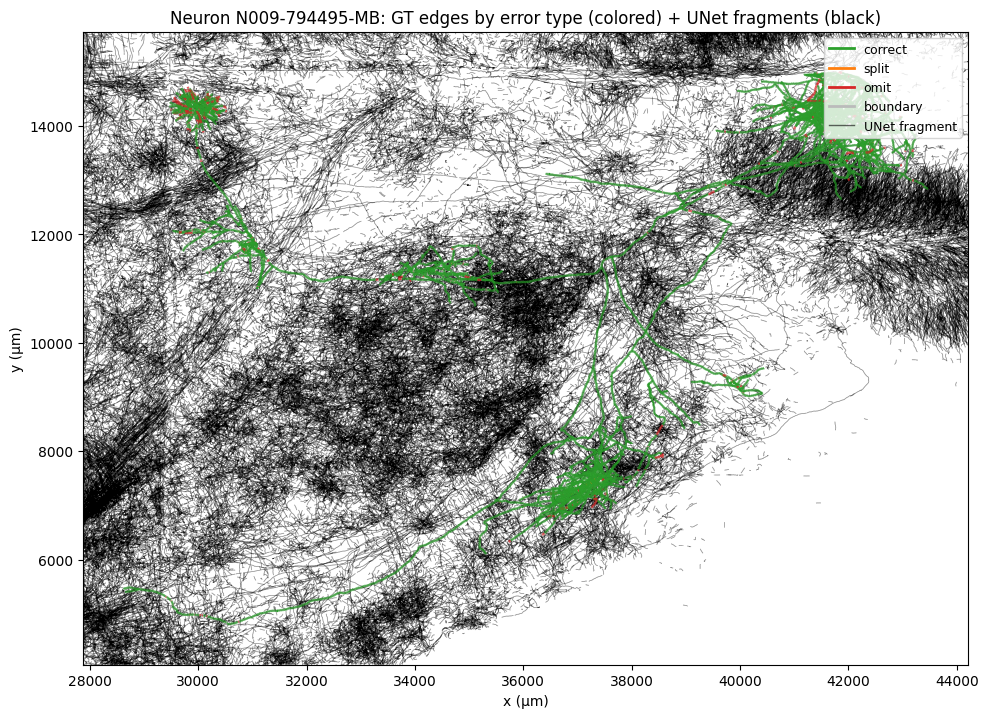

In [16]:
# Choose the GT neuron with the most split edges.
split_by_neuron = {n: per_neuron[n]["split"] for n in neurons}
focus = max(split_by_neuron, key=split_by_neuron.get)
focus_nodes = [n for n in gt_graph.nodes if gt_graph.node_segment_id(n) == focus]
fxyz = gt_graph.node_xyz[focus_nodes]
xmin, ymin = fxyz[:, 0].min(), fxyz[:, 1].min()
xmax, ymax = fxyz[:, 0].max(), fxyz[:, 1].max()
pad = 0.05 * max(xmax - xmin, ymax - ymin) + 1
print(f"focus neuron: {focus}  ({split_by_neuron[focus]} split edges)")

fig, ax = plt.subplots(figsize=(10, 10))

# GT edges of the focus neuron, colored by error type.
fsegs, fcols = [], []
for (i, j), cls in edge_class.items():
    if gt_graph.node_segment_id(i) == focus:
        (xi, yi), (xj, yj) = project(gt_graph.node_xyz[i]), project(gt_graph.node_xyz[j])
        fsegs.append([(xi, yi), (xj, yj)]); fcols.append(EDGE_COLORS[cls])
ax.add_collection(LineCollection(fsegs, colors=fcols, linewidths=1.6, zorder=3))

# Overlay fragment skeletons that fall in this bounding box (thin black).
fx = fragments_graph.node_xyz
in_box = (fx[:, 0] >= xmin - pad) & (fx[:, 0] <= xmax + pad) & \
         (fx[:, 1] >= ymin - pad) & (fx[:, 1] <= ymax + pad)
in_box_nodes = set(np.where(in_box)[0].tolist())
frag_segs = []
for i, j in fragments_graph.edges:
    if i in in_box_nodes and j in in_box_nodes:
        (xi, yi), (xj, yj) = project(fragments_graph.node_xyz[i]), project(fragments_graph.node_xyz[j])
        frag_segs.append([(xi, yi), (xj, yj)])
ax.add_collection(LineCollection(frag_segs, colors="black", linewidths=0.5, alpha=0.5, zorder=1))

ax.set_xlim(xmin - pad, xmax + pad); ax.set_ylim(ymin - pad, ymax + pad)
ax.set_aspect("equal"); ax.set_xlabel("x (µm)"); ax.set_ylabel("y (µm)")
ax.set_title(f"Neuron {focus}: GT edges by error type (colored) + UNet fragments (black)")
ax.legend(handles=legend_handles + [Line2D([0], [0], color="black", lw=1, alpha=0.6, label="UNet fragment")],
          loc="upper right", fontsize=9)
fig.tight_layout()
# fig.savefig(os.path.join(FIGS_DIR, "03_split_zoom.png"), dpi=150)
plt.show()

## 7c. Visualize the errors from the approx mask (not the KDTree proxy)

Section 7b colored GT edges using the **KDTree nearest-fragment** labels
(`gt_pred_label`). This section repeats that visualization for the patch built in
**section 7a**, but driven by the **approx-mask** labels (`approx_label`) — i.e. the
predicted label is read from the dilated, skeleton-reconstructed segmentation volume,
the same way the canonical pipeline reads the dense mask.

The edge-classification logic is **identical** to 7b (omit / split / correct, with the
omit-OR rule, same `EDGE_COLORS`); only the label *source* changes. We draw the two side
by side over the same patch so the difference is directly visible — in particular the
approx mask should show **fewer red (omit) edges**, because filling the space between
skeleton nodes recovers GT nodes the strict nearest-node tolerance leaves unmatched
(the effect quantified in 7a).

We then **quantify the consistency** of the two label sources on this patch:
- **node-level** — how often they agree on labeled-vs-omit, and on the actual
  segment id where both label a node;
- **edge-level** — a 3×3 confusion matrix of the two edge classifications, with
  overall agreement and **Cohen's κ** (chance-corrected). High κ ⇒ the cheap
  KDTree proxy is a faithful stand-in for the mask-style labeling; the off-diagonal
  cells localize exactly where they diverge.

In [ ]:
from collections import Counter

# Classify the in-patch GT edges from the APPROX-MASK labels (section 7a),
# using the EXACT same omit/split/correct logic as section 7b (omit = EITHER
# endpoint unlabeled) -- only the label source differs (approx_label vs the
# KDTree gt_pred_label).
def classify_edge_approx(i, j):
    li, lj = approx_label[i], approx_label[j]
    if li == "0" or lj == "0":
        return "omit"
    return "correct" if li == lj else "split"

approx_edge_class = {(i, j): classify_edge_approx(i, j)
                     for i, j in gt_graph.edges if i in idset and j in idset}

# For a fair side-by-side, classify the SAME in-patch edges via the KDTree proxy
# (classify_edge from section 7b reads gt_pred_label).
proxy_edge_class = {(i, j): classify_edge(i, j) for (i, j) in approx_edge_class}

ac, pc = Counter(approx_edge_class.values()), Counter(proxy_edge_class.values())
n_e = sum(ac.values())
print(f"in-patch GT edges: {n_e}")
print(f"{'class':<10}{'approx-mask':>16}{'KDTree proxy':>16}")
for k in ("correct", "split", "omit"):
    print(f"{k:<10}{ac[k]:>8} ({100*ac[k]/n_e:4.1f}%){pc[k]:>9} ({100*pc[k]/n_e:4.1f}%)")

# GT node coords in the local patch (z, y, x) voxels, keyed by node id.
node_local = {int(n): xyz for n, xyz in zip(gt_ids_patch, gt_local_patch)}

# Side-by-side patch error maps: approx-mask (left) vs KDTree proxy (right).
# Grey = rasterized fragment skeletons (the approx mask's source); colored GT
# edges use the SAME EDGE_COLORS / legend as section 7b.
fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharex=True, sharey=True)
for ax, (title, ec) in zip(
    axes,
    [("Approx mask (section 7a)", approx_edge_class),
     (f"KDTree proxy (tol={MATCH_TOL_UM} um)", proxy_edge_class)],
):
    for (s, e) in frag_edges:                          # rasterized fragment lines
        ax.plot([s[2], e[2]], [s[1], e[1]], color="#dddddd", lw=0.5, zorder=1)
    segs, cols = [], []
    for (i, j), cls in ec.items():
        pi, pj = node_local[i], node_local[j]
        segs.append([(pi[2], pi[1]), (pj[2], pj[1])])  # (x, y) projection
        cols.append(EDGE_COLORS[cls])
    ax.add_collection(LineCollection(segs, colors=cols, linewidths=1.5, zorder=3))
    c = Counter(ec.values())
    ax.set_title(f"{title}\ncorrect={c['correct']} split={c['split']} "
                 f"omit={c['omit']}")
    ax.set_aspect("equal"); ax.set_xlabel("x (voxel)")
    ax.legend(handles=legend_handles, loc="upper right", fontsize=8)
axes[0].set_ylabel("y (voxel)")
axes[0].autoscale()
fig.suptitle("Patch error classification — labels from approx mask vs. nearest-fragment proxy")
fig.tight_layout()
# fig.savefig(os.path.join(FIGS_DIR, "7c_approx_mask_errors.png"), dpi=150)
plt.show()

# ----------------------------------------------------------------------------
# How CONSISTENT are the two label sources? Quantify it at both levels.
# ----------------------------------------------------------------------------
# Node-level: do approx-mask and KDTree proxy agree on each GT node in the patch?
n_total = len(gt_ids_patch)
n_labelmatch = both_lab = segid_match = 0
for nid in gt_ids_patch:
    la, lk = approx_label[int(nid)], gt_pred_label[int(nid)]
    n_labelmatch += ((la == "0") == (lk == "0"))     # agree on labeled-vs-omit
    if la != "0" and lk != "0":
        both_lab += 1
        segid_match += (la == lk)                    # agree on the actual segment id
print("\nNODE-LEVEL consistency (approx mask vs KDTree proxy):")
print(f"  labeled-vs-omit agreement:           {100*n_labelmatch/n_total:.1f}%  ({n_labelmatch}/{n_total})")
print(f"  segment-id agreement (both labeled): "
      f"{(100*segid_match/both_lab if both_lab else float('nan')):.1f}%  ({segid_match}/{both_lab})")

# Edge-level: confusion matrix over the SAME in-patch edges (rows=approx, cols=proxy),
# plus overall agreement and Cohen's kappa (chance-corrected).
CLASSES = ["correct", "split", "omit"]
ci = {c: k for k, c in enumerate(CLASSES)}
cm = np.zeros((len(CLASSES), len(CLASSES)), dtype=int)
for e in approx_edge_class:
    cm[ci[approx_edge_class[e]], ci[proxy_edge_class[e]]] += 1
N = cm.sum()
po = np.trace(cm) / N                                                  # observed agreement
pe = sum((cm[i, :].sum() / N) * (cm[:, i].sum() / N) for i in range(len(CLASSES)))
kappa = (po - pe) / (1 - pe) if (1 - pe) else float("nan")

print(f"\nEDGE-LEVEL confusion matrix (rows = approx mask, cols = KDTree proxy), N={N}:")
print(f"{'approx / proxy':>15}" + "".join(f"{c:>10}" for c in CLASSES))
for i, c in enumerate(CLASSES):
    print(f"{c:>15}" + "".join(f"{cm[i, j]:>10}" for j in range(len(CLASSES))))
print(f"\noverall edge-class agreement: {100*po:.1f}%    Cohen's kappa: {kappa:.3f}")
print("(off-diagonal cells = edges the two methods classify differently; the dominant")
print(" disagreement is proxy 'omit' vs approx 'correct' — the recovered omits.)")

check("7c: patch error map rendered from approx-mask labels (same logic as 7b)", n_e > 0,
      f"{n_e} in-patch edges; approx omit={ac['omit']} vs proxy omit={pc['omit']}")
check("7c: approx-mask vs KDTree proxy consistency quantified (node + edge)",
      N > 0 and both_lab > 0,
      f"edge agree={100*po:.1f}%, kappa={kappa:.3f}, seg-id={100*segid_match/both_lab:.1f}%")

## 8. Verdict — is the markdown useful?

Summarizes every claim checked above. The point is whether a reader, **using only
the markdown**, can:
1. load the cache,
2. recover the right comparison key (predicted segment id, not component),
3. label GT nodes and classify edges,
4. produce split/merge counts.

Any FAIL below points to an instruction that is incomplete or misleading and
should be fixed in the markdown.

In [18]:
print("=" * 72)
n_pass = sum(1 for _, ok, _ in REPORT if ok)
for claim, ok, detail in REPORT:
    print(f"  [{'PASS' if ok else 'FAIL'}] {claim}")
print("=" * 72)
print(f"{n_pass}/{len(REPORT)} markdown claims verified from cache-only data.")
print()
print("KNOWN LIMITATIONS the markdown should make explicit (gaps surfaced by this test):")
print("  - The GT->fragment match tolerance ('~a few µm') is not a stored constant;")
print("    results (esp. % omit) depend on the MATCH_TOL_UM chosen above.")
print("  - Canonical scoring reads the dense segmentation MASK at each GT voxel; the")
print("    cache has only skeletons, so nearest-fragment-segment-id is a proxy. Fragments")
print("    shorter than min_cable_length were dropped, inflating apparent omits.")
print("  - Merge detection here tests the core definition (one segment -> many GT neurons);")
print("    the full geometric merge-site walk needs the mask.")

  [PASS] pickle is a single dict
  [PASS] key 'anisotropy' present
  [PASS] key 'min_cable_length' present
  [PASS] key 'node_spacing' present
  [PASS] key 'fragments_graph' present
  [PASS] key 'gt_graph' present
  [PASS] anisotropy == (0.748, 0.748, 1.0)
  [PASS] min_cable_length == 100
  [PASS] node_spacing == 5
  [PASS] both graphs have components to compare
  [PASS] gt_graph segment ids look like GT neuron names (contain '794495')
  [PASS] GT and fragment segment-id namespaces are disjoint
  [PASS] step 1 runs: every GT node received a predicted label or '0'
  [PASS] step 2 runs: edges classified into omit/split/correct
  [PASS] step 3 runs: split counts produced per neuron
  [PASS] step 4 runs: merge candidates identified
  [PASS] 7a: approximate mask built from skeletons alone (no cloud read)
  [PASS] 7a: error identification (steps 2-4) runs on approx-mask labels
  [PASS] 7a: approx-mask and KDTree proxy assign the SAME segment id where both label
  [PASS] 7c: patch error map r